In [1]:
!pip install librosa soundfile tensorflow transformers datasets accelerate scikit-learn seaborn matplotlib

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

DATASET_PATH = "/content/drive/MyDrive/RAVDESS"

print("Dataset Path:", DATASET_PATH)
print("Exists:", os.path.exists(DATASET_PATH))

Dataset Path: /content/drive/MyDrive/RAVDESS
Exists: True


In [4]:
actors = sorted([
    folder for folder in os.listdir(DATASET_PATH)
    if folder.startswith("Actor_")
])

print("Total Actor Folders:", len(actors))
print("\nActor Folders:")
print(actors)

Total Actor Folders: 24

Actor Folders:
['Actor_01', 'Actor_02', 'Actor_03', 'Actor_04', 'Actor_05', 'Actor_06', 'Actor_07', 'Actor_08', 'Actor_09', 'Actor_10', 'Actor_11', 'Actor_12', 'Actor_13', 'Actor_14', 'Actor_15', 'Actor_16', 'Actor_17', 'Actor_18', 'Actor_19', 'Actor_20', 'Actor_21', 'Actor_22', 'Actor_23', 'Actor_24']


In [5]:
total_files = 0

for actor in actors:
    actor_path = os.path.join(DATASET_PATH, actor)

    for file in os.listdir(actor_path):
        if file.lower().endswith(".wav"):
            total_files += 1

print("Total Audio Files:", total_files)

Total Audio Files: 1440


In [6]:
actor_01_path = os.path.join(DATASET_PATH, "Actor_01")

audio_files = [
    file for file in os.listdir(actor_01_path)
    if file.lower().endswith(".wav")
]

print("Number of files in Actor_01:", len(audio_files))
print("\nFirst 10 files:")

for file in sorted(audio_files)[:10]:
    print(file)

Number of files in Actor_01: 60

First 10 files:
03-01-01-01-01-01-01.wav
03-01-01-01-01-02-01.wav
03-01-01-01-02-01-01.wav
03-01-01-01-02-02-01.wav
03-01-02-01-01-01-01.wav
03-01-02-01-01-02-01.wav
03-01-02-01-02-01-01.wav
03-01-02-01-02-02-01.wav
03-01-02-02-01-01-01.wav
03-01-02-02-01-02-01.wav


In [7]:
# Check sample filenames
for file in sorted(audio_files)[:20]:
    parts = file.replace(".wav", "").split("-")
    emotion_code = parts[2]

    print(file, "→ Emotion Code:", emotion_code)

03-01-01-01-01-01-01.wav → Emotion Code: 01
03-01-01-01-01-02-01.wav → Emotion Code: 01
03-01-01-01-02-01-01.wav → Emotion Code: 01
03-01-01-01-02-02-01.wav → Emotion Code: 01
03-01-02-01-01-01-01.wav → Emotion Code: 02
03-01-02-01-01-02-01.wav → Emotion Code: 02
03-01-02-01-02-01-01.wav → Emotion Code: 02
03-01-02-01-02-02-01.wav → Emotion Code: 02
03-01-02-02-01-01-01.wav → Emotion Code: 02
03-01-02-02-01-02-01.wav → Emotion Code: 02
03-01-02-02-02-01-01.wav → Emotion Code: 02
03-01-02-02-02-02-01.wav → Emotion Code: 02
03-01-03-01-01-01-01.wav → Emotion Code: 03
03-01-03-01-01-02-01.wav → Emotion Code: 03
03-01-03-01-02-01-01.wav → Emotion Code: 03
03-01-03-01-02-02-01.wav → Emotion Code: 03
03-01-03-02-01-01-01.wav → Emotion Code: 03
03-01-03-02-01-02-01.wav → Emotion Code: 03
03-01-03-02-02-01-01.wav → Emotion Code: 03
03-01-03-02-02-02-01.wav → Emotion Code: 03


In [8]:
import pandas as pd
import os

# RAVDESS emotion mapping
emotion_map = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised"
}

data = []

for actor in actors:
    actor_path = os.path.join(DATASET_PATH, actor)

    for file in os.listdir(actor_path):
        if file.lower().endswith(".wav"):

            # Extract emotion code from filename
            parts = file.replace(".wav", "").split("-")
            emotion_code = parts[2]

            # Convert code to emotion
            emotion = emotion_map[emotion_code]

            # Full audio path
            file_path = os.path.join(actor_path, file)

            data.append({
                "file_path": file_path,
                "filename": file,
                "emotion_code": emotion_code,
                "emotion": emotion,
                "actor": actor
            })

df = pd.DataFrame(data)

print("Total Audio Files:", len(df))
df.head()

Total Audio Files: 1440


,file_path,filename,emotion_code,emotion,actor
0,/content/drive/MyDrive/RAVDESS/Actor_01/03-01-...,03-01-01-01-01-01-01.wav,01,neutral,Actor_01
1,/content/drive/MyDrive/RAVDESS/Actor_01/03-01-...,03-01-01-01-02-02-01.wav,01,neutral,Actor_01
2,/content/drive/MyDrive/RAVDESS/Actor_01/03-01-...,03-01-02-01-01-02-01.wav,02,calm,Actor_01
3,/content/drive/MyDrive/RAVDESS/Actor_01/03-01-...,03-01-02-01-01-01-01.wav,02,calm,Actor_01
4,/content/drive/MyDrive/RAVDESS/Actor_01/03-01-...,03-01-01-01-02-01-01.wav,01,neutral,Actor_01


In [9]:
print(df["emotion"].value_counts())

emotion
calm         192
happy        192
sad          192
angry        192
disgust      192
fearful      192
surprised    192
neutral       96
Name: count, dtype: int64


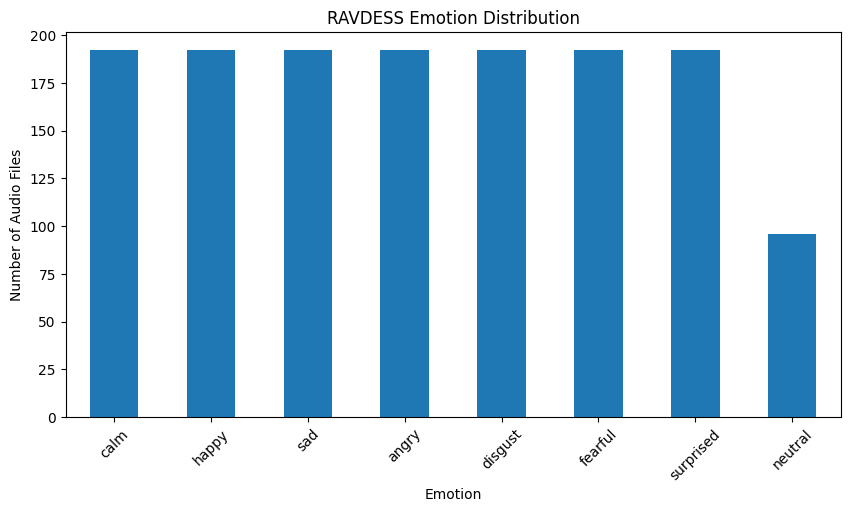

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

df["emotion"].value_counts().plot(kind="bar")

plt.title("RAVDESS Emotion Distribution")
plt.xlabel("Emotion")
plt.ylabel("Number of Audio Files")
plt.xticks(rotation=45)
plt.show()

In [11]:
import librosa
import librosa.display
import matplotlib.pyplot as plt

# Select first audio file
audio_path = df.iloc[0]["file_path"]

# Load audio
audio, sample_rate = librosa.load(audio_path, sr=None)

print("Audio File:", df.iloc[0]["filename"])
print("Emotion:", df.iloc[0]["emotion"])
print("Actor:", df.iloc[0]["actor"])
print("Sample Rate:", sample_rate)
print("Audio Duration:", round(len(audio) / sample_rate, 2), "seconds")
print("Number of Samples:", len(audio))

Audio File: 03-01-01-01-01-01-01.wav
Emotion: neutral
Actor: Actor_01
Sample Rate: 48000
Audio Duration: 3.3 seconds
Number of Samples: 158558


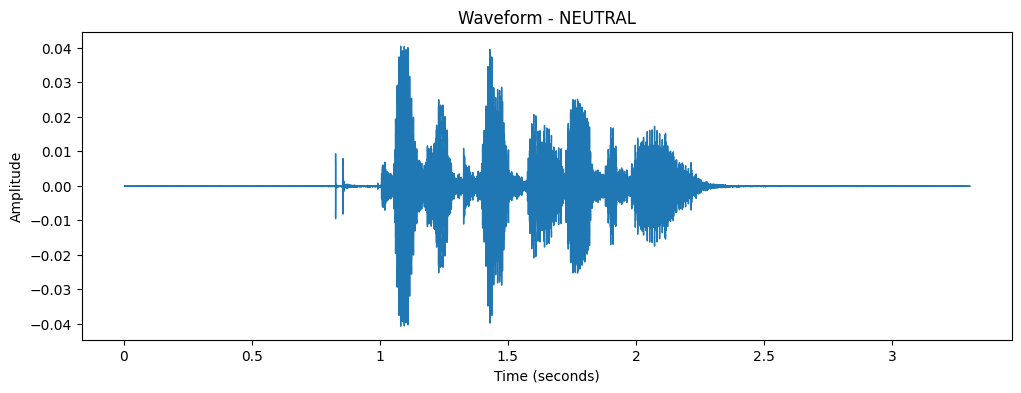

In [12]:
plt.figure(figsize=(12, 4))

librosa.display.waveshow(audio, sr=sample_rate)

plt.title(f"Waveform - {df.iloc[0]['emotion'].upper()}")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.show()

In [13]:
mfcc = librosa.feature.mfcc(
    y=audio,
    sr=sample_rate,
    n_mfcc=40
)

print("MFCC Shape:", mfcc.shape)

MFCC Shape: (40, 310)


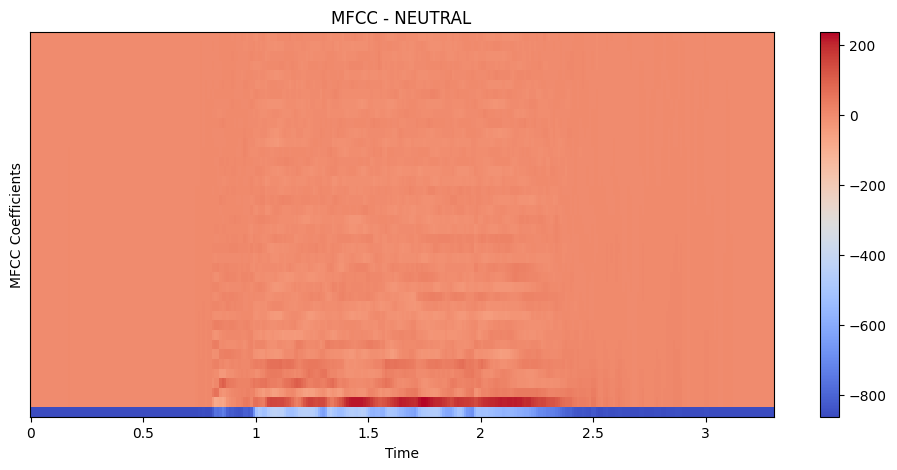

In [14]:
plt.figure(figsize=(12, 5))

librosa.display.specshow(
    mfcc,
    x_axis="time",
    sr=sample_rate
)

plt.colorbar()
plt.title(f"MFCC - {df.iloc[0]['emotion'].upper()}")
plt.xlabel("Time")
plt.ylabel("MFCC Coefficients")
plt.show()

In [15]:
# Define actors for each split

train_actors = [f"Actor_{i:02d}" for i in range(1, 17)]
val_actors   = [f"Actor_{i:02d}" for i in range(17, 21)]
test_actors  = [f"Actor_{i:02d}" for i in range(21, 25)]

# Create split column

def assign_split(actor):
    if actor in train_actors:
        return "train"
    elif actor in val_actors:
        return "validation"
    elif actor in test_actors:
        return "test"

df["split"] = df["actor"].apply(assign_split)

print("Training:", len(df[df["split"] == "train"]))
print("Validation:", len(df[df["split"] == "validation"]))
print("Testing:", len(df[df["split"] == "test"]))

Training: 960
Validation: 240
Testing: 240


In [16]:
split_emotion_counts = pd.crosstab(
    df["emotion"],
    df["split"]
)

print(split_emotion_counts)

split      test  train  validation
emotion                           
angry        32    128          32
calm         32    128          32
disgust      32    128          32
fearful      32    128          32
happy        32    128          32
neutral      16     64          16
sad          32    128          32
surprised    32    128          32


In [17]:
import numpy as np
import librosa

# MFCC settings
SAMPLE_RATE = 16000
N_MFCC = 40
MAX_LEN = 200


def extract_mfcc(file_path):
    try:
        # Load audio and resample to 16 kHz
        audio, sr = librosa.load(
            file_path,
            sr=SAMPLE_RATE
        )

        # Extract MFCC
        mfcc = librosa.feature.mfcc(
            y=audio,
            sr=sr,
            n_mfcc=N_MFCC
        )

        # Fix number of time frames
        if mfcc.shape[1] < MAX_LEN:
            # Padding
            pad_width = MAX_LEN - mfcc.shape[1]
            mfcc = np.pad(
                mfcc,
                ((0, 0), (0, pad_width)),
                mode="constant"
            )

        else:
            # Truncation
            mfcc = mfcc[:, :MAX_LEN]

        return mfcc

    except Exception as e:
        print("Error:", file_path)
        print(e)
        return None

In [18]:
sample_path = df.iloc[0]["file_path"]

sample_mfcc = extract_mfcc(sample_path)

print("MFCC Shape:", sample_mfcc.shape)
print("Data Type:", sample_mfcc.dtype)

MFCC Shape: (40, 200)
Data Type: float32


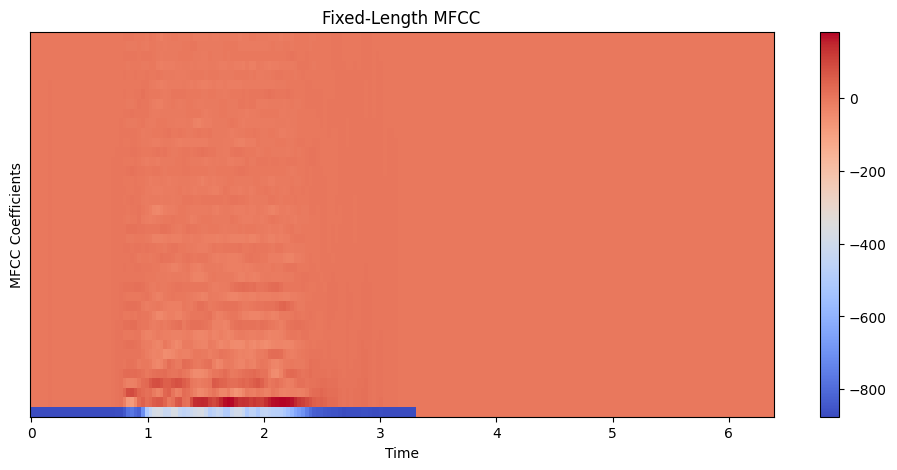

In [19]:
plt.figure(figsize=(12, 5))

librosa.display.specshow(
    sample_mfcc,
    x_axis="time",
    sr=SAMPLE_RATE
)

plt.colorbar()
plt.title("Fixed-Length MFCC")
plt.xlabel("Time")
plt.ylabel("MFCC Coefficients")

plt.show()

In [20]:
from tqdm import tqdm
import numpy as np

X = []
y = []

# Emotion to numerical label
label_map = {
    "angry": 0,
    "calm": 1,
    "disgust": 2,
    "fearful": 3,
    "happy": 4,
    "neutral": 5,
    "sad": 6,
    "surprised": 7
}

for _, row in tqdm(df.iterrows(), total=len(df)):

    mfcc = extract_mfcc(row["file_path"])

    if mfcc is not None:
        X.append(mfcc)
        y.append(label_map[row["emotion"]])

# Convert to NumPy arrays
X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.int32)

print("X Shape:", X.shape)
print("y Shape:", y.shape)

100%|██████████| 1440/1440 [11:05<00:00,  2.16it/s]

X Shape: (1440, 40, 200)
y Shape: (1440,)


In [21]:
# Create masks based on the split column
train_mask = df["split"] == "train"
val_mask = df["split"] == "validation"
test_mask = df["split"] == "test"

# Split MFCC features
X_train = X[train_mask.values]
X_val   = X[val_mask.values]
X_test  = X[test_mask.values]

# Split labels
y_train = y[train_mask.values]
y_val   = y[val_mask.values]
y_test  = y[test_mask.values]

print("Training:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nValidation:")
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("\nTesting:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Training:
X_train: (960, 40, 200)
y_train: (960,)

Validation:
X_val: (240, 40, 200)
y_val: (240,)

Testing:
X_test: (240, 40, 200)
y_test: (240,)


In [22]:
# Calculate mean and standard deviation from training data only

train_mean = np.mean(X_train, axis=(0, 2), keepdims=True)
train_std = np.std(X_train, axis=(0, 2), keepdims=True)

# Avoid division by zero
train_std = np.where(train_std == 0, 1e-8, train_std)

# Normalize all splits using training statistics
X_train_norm = (X_train - train_mean) / train_std
X_val_norm   = (X_val - train_mean) / train_std
X_test_norm  = (X_test - train_mean) / train_std

print("Training mean:", train_mean.shape)
print("Training std:", train_std.shape)

print("\nNormalized shapes:")
print("X_train_norm:", X_train_norm.shape)
print("X_val_norm:", X_val_norm.shape)
print("X_test_norm:", X_test_norm.shape)

Training mean: (1, 40, 1)
Training std: (1, 40, 1)

Normalized shapes:
X_train_norm: (960, 40, 200)
X_val_norm: (240, 40, 200)
X_test_norm: (240, 40, 200)


In [23]:
print("Mean after normalization:",
      np.mean(X_train_norm))

print("Std after normalization:",
      np.std(X_train_norm))

Mean after normalization: -1.5505154e-08
Std after normalization: 1.0000001


In [24]:
# Convert MFCC data for LSTM

X_train_lstm = np.transpose(X_train_norm, (0, 2, 1))
X_val_lstm   = np.transpose(X_val_norm, (0, 2, 1))
X_test_lstm  = np.transpose(X_test_norm, (0, 2, 1))

print("X_train_lstm:", X_train_lstm.shape)
print("X_val_lstm:", X_val_lstm.shape)
print("X_test_lstm:", X_test_lstm.shape)

X_train_lstm: (960, 200, 40)
X_val_lstm: (240, 200, 40)
X_test_lstm: (240, 200, 40)


In [25]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Bidirectional,
    LSTM,
    Dense,
    Dropout
)

# Build BiLSTM model
bilstm_model = Sequential([

    Input(shape=(200, 40)),

    Bidirectional(
        LSTM(128, return_sequences=True)
    ),
    Dropout(0.3),

    Bidirectional(
        LSTM(64)
    ),
    Dropout(0.3),

    Dense(64, activation="relu"),
    Dropout(0.3),

    Dense(8, activation="softmax")
])

# Compile
bilstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Show architecture
bilstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 200, 256)       │       173,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 200, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 346,184 (1.32 MB)

 Trainable params: 346,184 (1.32 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:
print("Total Parameters:",
      bilstm_model.count_params())

Total Parameters: 346184


In [27]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_bilstm.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max"
)

history_bilstm = bilstm_model.fit(
    X_train_lstm,
    y_train,
    validation_data=(X_val_lstm, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[
        early_stopping,
        checkpoint
    ],
    verbose=1
)

Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 8s 75ms/step - accuracy: 0.1250 - loss: 2.0773 - val_accuracy: 0.1417 - val_loss: 2.0501
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.2042 - loss: 2.0155 - val_accuracy: 0.2000 - val_loss: 1.9971
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.2417 - loss: 1.8938 - val_accuracy: 0.2917 - val_loss: 1.9078
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.2948 - loss: 1.7949 - val_accuracy: 0.2708 - val_loss: 1.9175
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.3531 - loss: 1.6904 - val_accuracy: 0.2833 - val_loss: 1.8667
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.4021 - loss: 1.6046 - val_accuracy: 0.3042 - val_loss: 1.8605
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.4406 - loss: 1.4851 - val_accuracy: 0.2458 - val_loss: 2.0174
Epoch 8/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.4573 - loss: 1.4796 - val_accuracy: 0.2542 - v

In [28]:
print("Training completed.")
print("Best model weights have been restored.")

Training completed.
Best model weights have been restored.


In [29]:
test_loss, test_accuracy = bilstm_model.evaluate(
    X_test_lstm,
    y_test,
    verbose=1
)

print(f"\nBiLSTM Test Loss: {test_loss:.4f}")
print(f"BiLSTM Test Accuracy: {test_accuracy:.4f}")
print(f"BiLSTM Test Accuracy: {test_accuracy * 100:.2f}%")

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.2583 - loss: 1.8068

BiLSTM Test Loss: 1.8068
BiLSTM Test Accuracy: 0.2583
BiLSTM Test Accuracy: 25.83%


In [30]:
from sklearn.metrics import classification_report
import numpy as np

# Predict test data
y_pred_probs = bilstm_model.predict(X_test_lstm)
y_pred = np.argmax(y_pred_probs, axis=1)

# Emotion names in label order
emotion_names = [
    "angry",
    "calm",
    "disgust",
    "fearful",
    "happy",
    "neutral",
    "sad",
    "surprised"
]

# Classification report
print(classification_report(
    y_test,
    y_pred,
    target_names=emotion_names,
    digits=4
))

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step
              precision    recall  f1-score   support

       angry     0.3962    0.6562    0.4941        32
        calm     0.4054    0.4688    0.4348        32
     disgust     0.3636    0.1250    0.1860        32
     fearful     0.2593    0.2188    0.2373        32
       happy     0.1429    0.0312    0.0513        32
     neutral     0.0000    0.0000    0.0000        16
         sad     0.2069    0.1875    0.1967        32
   surprised     0.1067    0.2500    0.1495        32

    accuracy                         0.2583       240
   macro avg     0.2351    0.2422    0.2187       240
weighted avg     0.2508    0.2583    0.2333       240



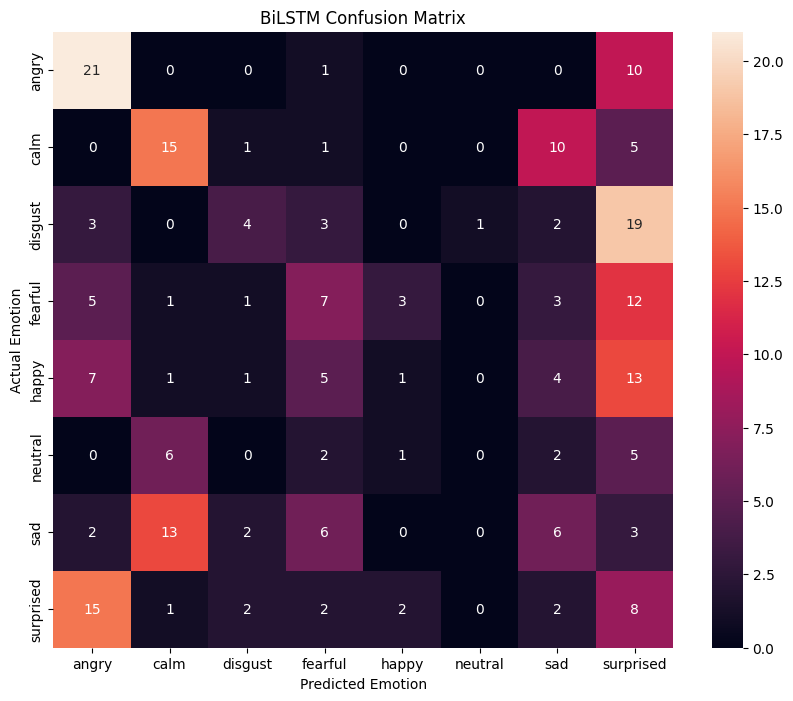

In [31]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=emotion_names,
    yticklabels=emotion_names
)

plt.title("BiLSTM Confusion Matrix")
plt.xlabel("Predicted Emotion")
plt.ylabel("Actual Emotion")
plt.show()

In [32]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv1D,
    MaxPooling1D,
    BatchNormalization,
    LSTM,
    Dense,
    Dropout
)

cnn_lstm_model = Sequential([

    Input(shape=(200, 40)),

    # CNN Feature Extraction
    Conv1D(
        filters=64,
        kernel_size=5,
        activation="relu",
        padding="same"
    ),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.25),

    Conv1D(
        filters=128,
        kernel_size=3,
        activation="relu",
        padding="same"
    ),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.30),

    # Temporal Learning
    LSTM(
        128,
        return_sequences=True
    ),
    Dropout(0.30),

    LSTM(64),
    Dropout(0.30),

    # Classification
    Dense(64, activation="relu"),
    Dropout(0.30),

    Dense(8, activation="softmax")
])

cnn_lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 200, 64)        │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 200, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 100, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 100, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 100, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 100, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 50, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 50, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 50, 128)        │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 50, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 224,008 (875.03 KB)

 Trainable params: 223,624 (873.53 KB)

 Non-trainable params: 384 (1.50 KB)

In [33]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

cnn_early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=1
)

cnn_checkpoint = ModelCheckpoint(
    "best_cnn_lstm.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    min_lr=1e-6,
    verbose=1
)

In [34]:
cnn_test_loss, cnn_test_accuracy = cnn_lstm_model.evaluate(
    X_test_lstm,
    y_test,
    verbose=1
)

print(
    f"CNN-LSTM Test Loss: "
    f"{cnn_test_loss:.4f}"
)

print(
    f"CNN-LSTM Test Accuracy: "
    f"{cnn_test_accuracy * 100:.2f}%"
)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.1375 - loss: 2.0789
CNN-LSTM Test Loss: 2.0789
CNN-LSTM Test Accuracy: 13.75%


In [35]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

cnn_early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=1
)

cnn_checkpoint = ModelCheckpoint(
    "best_cnn_lstm.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    min_lr=1e-6,
    verbose=1
)

history_cnn_lstm = cnn_lstm_model.fit(
    X_train_lstm,
    y_train,

    validation_data=(
        X_val_lstm,
        y_val
    ),

    epochs=60,
    batch_size=32,

    callbacks=[
        cnn_early_stop,
        cnn_checkpoint,
        reduce_lr
    ],

    verbose=1
)

Epoch 1/60
28/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.1633 - loss: 2.1051
Epoch 1: val_accuracy improved from None to 0.13333, saving model to best_cnn_lstm.keras

Epoch 1: finished saving model to best_cnn_lstm.keras
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.1417 - loss: 2.1041 - val_accuracy: 0.1333 - val_loss: 2.0733 - learning_rate: 0.0010
Epoch 2/60
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.1192 - loss: 2.0931
Epoch 2: val_accuracy improved from 0.13333 to 0.15833, saving model to best_cnn_lstm.keras

Epoch 2: finished saving model to best_cnn_lstm.keras
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.1219 - loss: 2.0896 - val_accuracy: 0.1583 - val_loss: 2.0665 - learning_rate: 0.0010
Epoch 3/60
27/30 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.1486 - loss: 2.0703
Epoch 3: val_accuracy did not improve from 0.15833
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.1375 - loss: 2.0725 - val_accuracy: 0.1000 - val_loss: 2.0665 - learn

In [36]:
cnn_test_loss, cnn_test_accuracy = cnn_lstm_model.evaluate(
    X_test_lstm,
    y_test,
    verbose=1
)

print(f"CNN-LSTM Test Loss: {cnn_test_loss:.4f}")
print(f"CNN-LSTM Test Accuracy: {cnn_test_accuracy * 100:.2f}%")

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2792 - loss: 1.7761 
CNN-LSTM Test Loss: 1.7761
CNN-LSTM Test Accuracy: 27.92%


In [37]:
!pip install -q transformers datasets accelerate evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.9 MB/s eta 0:00:00


In [38]:
import tensorflow as tf
import torch

print("TensorFlow GPU:")
print(tf.config.list_physical_devices("GPU"))

print("\nPyTorch GPU Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

TensorFlow GPU:
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

PyTorch GPU Available: True
GPU: Tesla T4


In [39]:
from datasets import Dataset, Audio

# Keep only required columns
wav_df = df[[
    "file_path",
    "emotion",
    "split"
]].copy()

# Rename columns
wav_df = wav_df.rename(columns={
    "file_path": "audio",
    "emotion": "label"
})

# Convert emotion names to numerical labels
wav_df["label"] = wav_df["label"].map(label_map)

# Reset index
wav_df = wav_df.reset_index(drop=True)

print(wav_df.head())
print("\nTotal samples:", len(wav_df))

                                               audio  label  split
0  /content/drive/MyDrive/RAVDESS/Actor_01/03-01-...      5  train
1  /content/drive/MyDrive/RAVDESS/Actor_01/03-01-...      5  train
2  /content/drive/MyDrive/RAVDESS/Actor_01/03-01-...      1  train
3  /content/drive/MyDrive/RAVDESS/Actor_01/03-01-...      1  train
4  /content/drive/MyDrive/RAVDESS/Actor_01/03-01-...      5  train

Total samples: 1440


In [40]:
train_df = wav_df[wav_df["split"] == "train"].reset_index(drop=True)
val_df   = wav_df[wav_df["split"] == "validation"].reset_index(drop=True)
test_df  = wav_df[wav_df["split"] == "test"].reset_index(drop=True)

train_dataset = Dataset.from_pandas(
    train_df[["audio", "label"]],
    preserve_index=False
)

val_dataset = Dataset.from_pandas(
    val_df[["audio", "label"]],
    preserve_index=False
)

test_dataset = Dataset.from_pandas(
    test_df[["audio", "label"]],
    preserve_index=False
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 960
Validation: 240
Test: 240


In [41]:
train_dataset = train_dataset.cast_column(
    "audio",
    Audio(sampling_rate=16000)
)

val_dataset = val_dataset.cast_column(
    "audio",
    Audio(sampling_rate=16000)
)

test_dataset = test_dataset.cast_column(
    "audio",
    Audio(sampling_rate=16000)
)

print(train_dataset[0])

{'audio': <datasets.features._torchcodec.AudioDecoder object at 0x7b1b71330590>, 'label': 5}


In [42]:
from transformers import AutoFeatureExtractor

MODEL_NAME = "facebook/wav2vec2-base"

feature_extractor = AutoFeatureExtractor.from_pretrained(
    MODEL_NAME
)

print("Feature extractor loaded successfully.")

preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.84k [00:00<?, ?B/s]

Feature extractor loaded successfully.


In [43]:
def prepare_audio(batch):
    audio = batch["audio"]

    inputs = feature_extractor(
        audio["array"],
        sampling_rate=16000
    )

    return {
        "input_values": inputs["input_values"][0],
        "labels": batch["label"]
    }


train_w2v = train_dataset.map(
    prepare_audio,
    remove_columns=["audio"],
    desc="Processing Training Audio"
)

val_w2v = val_dataset.map(
    prepare_audio,
    remove_columns=["audio"],
    desc="Processing Validation Audio"
)

test_w2v = test_dataset.map(
    prepare_audio,
    remove_columns=["audio"],
    desc="Processing Test Audio"
)

print("Train:", len(train_w2v))
print("Validation:", len(val_w2v))
print("Test:", len(test_w2v))

Processing Training Audio:   0%|          | 0/960 [00:00<?, ? examples/s]

Processing Validation Audio:   0%|          | 0/240 [00:00<?, ? examples/s]

Processing Test Audio:   0%|          | 0/240 [00:00<?, ? examples/s]

Train: 960
Validation: 240
Test: 240


In [44]:
sample = train_w2v[0]

print("Available keys:", sample.keys())
print("Input length:", len(sample["input_values"]))
print("Label:", sample["labels"])

Available keys: dict_keys(['label', 'input_values', 'labels'])
Input length: 52853
Label: 5


In [45]:
# Remove the unnecessary original label column

train_w2v = train_w2v.remove_columns(["label"])
val_w2v = val_w2v.remove_columns(["label"])
test_w2v = test_w2v.remove_columns(["label"])

print("Train columns:", train_w2v.column_names)
print("Validation columns:", val_w2v.column_names)
print("Test columns:", test_w2v.column_names)

Train columns: ['input_values', 'labels']
Validation columns: ['input_values', 'labels']
Test columns: ['input_values', 'labels']


In [46]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(labels, predictions)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="weighted",
        zero_division=0
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

print("Metrics function ready.")

Metrics function ready.


In [47]:
from transformers import TrainingArguments

# Number of training samples: 960
# per_device_train_batch_size: 4
# num_train_epochs: 10
# gradient_accumulation_steps: 2

# Effective batch size = per_device_train_batch_size * gradient_accumulation_steps = 4 * 2 = 8
# Steps per epoch = num_training_samples / effective_batch_size = 960 / 8 = 120
# Total steps = steps_per_epoch * num_train_epochs = 120 * 10 = 1200
# Warmup steps = total_steps * warmup_ratio = 1200 * 0.1 = 120

training_args = TrainingArguments(
    output_dir="./wav2vec2-emotion",

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=1e-5,

    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,

    gradient_accumulation_steps=2,

    num_train_epochs=10,

    warmup_steps=120,

    logging_steps=25,

    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,

    save_total_limit=2,

    report_to="none",

    fp16=torch.cuda.is_available()
)

print("Training arguments ready.")

Training arguments ready.


In [48]:
from transformers import Wav2Vec2ForSequenceClassification

id2label = {
    0: "angry",
    1: "calm",
    2: "disgust",
    3: "fearful",
    4: "happy",
    5: "neutral",
    6: "sad",
    7: "surprised"
}

label2id = {label: idx for idx, label in id2label.items()}

wav2vec_model = Wav2Vec2ForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=8,
    label2id=label2id,
    id2label=id2label,
    problem_type="single_label_classification"
)

wav2vec_model.freeze_feature_encoder()

print("Wav2Vec2 model loaded successfully.")

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  380MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

[transformers] Wav2Vec2ForSequenceClassification LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     | 
-----------------------------+------------+-
quantizer.weight_proj.weight | UNEXPECTED | 
quantizer.weight_proj.bias   | UNEXPECTED | 
quantizer.codevectors        | UNEXPECTED | 
project_hid.weight           | UNEXPECTED | 
project_q.weight             | UNEXPECTED | 
project_q.bias               | UNEXPECTED | 
project_hid.bias             | UNEXPECTED | 
projector.weight             | MISSING    | 
projector.bias               | MISSING    | 
classifier.weight            | MISSING    | 
classifier.bias              | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Wav2Vec2 model loaded successfully.


In [49]:
from dataclasses import dataclass
import torch

@dataclass
class DataCollatorAudio:
    processor: object

    def __call__(self, features):
        input_features = [
            {"input_values": feature["input_values"]}
            for feature in features
        ]

        labels = torch.tensor(
            [feature["labels"] for feature in features],
            dtype=torch.long
        )

        batch = self.processor.pad(
            input_features,
            padding=True,
            return_tensors="pt"
        )

        batch["labels"] = labels

        return batch


data_collator = DataCollatorAudio(
    processor=feature_extractor
)

print("Data collator ready.")

Data collator ready.


In [50]:
from transformers import Trainer

trainer = Trainer(
    model=wav2vec_model,
    args=training_args,
    train_dataset=train_w2v,
    eval_dataset=val_w2v,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

print("Trainer is ready.")

model.safetensors: reconstructing file:   0%|          |  0.00B /  380MB            

model.safetensors: downloading bytes:           |  0.00B            

Trainer is ready.


In [51]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,4.112080,2.004456,0.291667,0.369305,0.291667,0.250906
2,3.493027,1.745772,0.341667,0.317513,0.341667,0.266968
3,2.955435,1.552647,0.450000,0.434670,0.450000,0.372182
4,2.587280,1.357318,0.579167,0.563174,0.579167,0.544866
5,2.170049,1.243854,0.620833,0.663837,0.620833,0.603695
6,1.894658,1.153788,0.691667,0.699501,0.691667,0.682926
7,1.791787,1.112241,0.695833,0.696479,0.695833,0.688611
8,1.509180,1.052336,0.712500,0.718156,0.712500,0.706440
9,1.389902,1.043190,0.733333,0.738601,0.733333,0.726999
10,1.295735,1.012062,0.745833,0.747568,0.745833,0.740637


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1200, training_loss=2.3928050740559894, metrics={'train_runtime': 819.6922, 'train_samples_per_second': 11.712, 'train_steps_per_second': 1.464, 'total_flos': 3.484673681694641e+17, 'train_loss': 2.3928050740559894, 'epoch': 10.0})

In [52]:
test_results = trainer.predict(test_w2v)

print("Test Loss:", test_results.metrics["test_loss"])
print("Test Accuracy:", test_results.metrics["test_accuracy"])
print("Test F1:", test_results.metrics["test_f1"])

Test Loss: 1.1569041013717651
Test Accuracy: 0.6333333333333333
Test F1: 0.6294048491639952


In [53]:
import torch

print("GPU:", torch.cuda.get_device_name(0))
print("CUDA available:", torch.cuda.is_available())

GPU: Tesla T4
CUDA available: True


In [54]:
from transformers import AutoFeatureExtractor, Wav2Vec2ForSequenceClassification

MODEL_NAME_XLSR = "facebook/wav2vec2-large-xlsr-53"

# Feature extractor
feature_extractor_xlsr = AutoFeatureExtractor.from_pretrained(
    MODEL_NAME_XLSR
)

# Labels
id2label = {
    0: "angry",
    1: "calm",
    2: "disgust",
    3: "fearful",
    4: "happy",
    5: "neutral",
    6: "sad",
    7: "surprised"
}

label2id = {label: idx for idx, label in id2label.items()}

# Load model
wav2vec_xlsr = Wav2Vec2ForSequenceClassification.from_pretrained(
    MODEL_NAME_XLSR,
    num_labels=8,
    label2id=label2id,
    id2label=id2label,
    problem_type="single_label_classification"
)

# Freeze only the low-level feature extractor
wav2vec_xlsr.freeze_feature_encoder()

print("Wav2Vec2 XLSR model loaded successfully.")

preprocessor_config.json:   0%|          | 0.00/212 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.77k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B / 1.27GB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/422 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.27GB            

[transformers] Wav2Vec2ForSequenceClassification LOAD REPORT from: facebook/wav2vec2-large-xlsr-53
Key                          | Status     | 
-----------------------------+------------+-
quantizer.weight_proj.weight | UNEXPECTED | 
quantizer.weight_proj.bias   | UNEXPECTED | 
quantizer.codevectors        | UNEXPECTED | 
project_hid.weight           | UNEXPECTED | 
project_q.weight             | UNEXPECTED | 
project_q.bias               | UNEXPECTED | 
project_hid.bias             | UNEXPECTED | 
classifier.weight            | MISSING    | 
projector.weight             | MISSING    | 
projector.bias               | MISSING    | 
classifier.bias              | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Wav2Vec2 XLSR model loaded successfully.


model.safetensors: downloading bytes:           |  0.00B            

In [55]:
from dataclasses import dataclass
import torch

@dataclass
class XLSRAudioCollator:
    processor: object

    def __call__(self, features):
        input_features = [
            {"input_values": feature["input_values"]}
            for feature in features
        ]

        labels = torch.tensor(
            [feature["labels"] for feature in features],
            dtype=torch.long
        )

        batch = self.processor.pad(
            input_features,
            padding=True,
            return_tensors="pt"
        )

        batch["labels"] = labels

        return batch


xlsr_data_collator = XLSRAudioCollator(
    processor=feature_extractor_xlsr
)

print("XLSR data collator ready.")

XLSR data collator ready.


In [56]:
from transformers import TrainingArguments
import torch

xlsr_training_args = TrainingArguments(
    output_dir="./wav2vec2-xlsr-emotion",

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=1e-4,

    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,

    gradient_accumulation_steps=4,

    num_train_epochs=15,

    warmup_steps=180,

    logging_steps=25,

    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,

    save_total_limit=2,

    report_to="none",

    fp16=True
)

print("XLSR training arguments ready.")

XLSR training arguments ready.


In [57]:
from transformers import Trainer

xlsr_trainer = Trainer(
    model=wav2vec_xlsr,
    args=xlsr_training_args,
    train_dataset=train_w2v,
    eval_dataset=val_w2v,
    data_collator=xlsr_data_collator,
    compute_metrics=compute_metrics
)

print("XLSR Trainer is ready.")

XLSR Trainer is ready.


In [59]:
xlsr_trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.606599,1.574950,0.695833,0.729701,0.695833,0.698913
2,2.126387,1.417146,0.716667,0.751207,0.716667,0.722813
3,1.250545,1.499019,0.733333,0.761091,0.733333,0.725928
4,1.391449,1.556990,0.729167,0.763261,0.729167,0.733442
5,2.535782,1.823496,0.687500,0.735686,0.687500,0.690379
6,1.021571,1.569715,0.750000,0.772569,0.750000,0.750280
7,0.337043,1.894892,0.754167,0.790794,0.754167,0.749496
8,0.655808,1.755953,0.754167,0.759429,0.754167,0.751050
9,0.700564,1.940621,0.741667,0.739232,0.741667,0.732233
10,0.168205,1.692204,0.766667,0.775026,0.766667,0.760222


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1800, training_loss=0.6896005454328326, metrics={'train_runtime': 3818.1115, 'train_samples_per_second': 3.771, 'train_steps_per_second': 0.471, 'total_flos': 1.6744655017879127e+18, 'train_loss': 0.6896005454328326, 'epoch': 15.0})

In [60]:
xlsr_test_results = xlsr_trainer.predict(test_w2v)

print("XLSR Test Loss:", xlsr_test_results.metrics["test_loss"])
print("XLSR Test Accuracy:", xlsr_test_results.metrics["test_accuracy"])
print("XLSR Test Precision:", xlsr_test_results.metrics["test_precision"])
print("XLSR Test Recall:", xlsr_test_results.metrics["test_recall"])
print("XLSR Test F1:", xlsr_test_results.metrics["test_f1"])

XLSR Test Loss: 1.7026020288467407
XLSR Test Accuracy: 0.7875
XLSR Test Precision: 0.8255096816476127
XLSR Test Recall: 0.7875
XLSR Test F1: 0.787294444200486


In [61]:
from sklearn.metrics import classification_report
import numpy as np

xlsr_predictions = np.argmax(
    xlsr_test_results.predictions,
    axis=-1
)

xlsr_true_labels = xlsr_test_results.label_ids

print(
    classification_report(
        xlsr_true_labels,
        xlsr_predictions,
        target_names=[
            "angry",
            "calm",
            "disgust",
            "fearful",
            "happy",
            "neutral",
            "sad",
            "surprised"
        ],
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

       angry     0.8000    0.8750    0.8358        32
        calm     0.9167    0.6875    0.7857        32
     disgust     0.9286    0.8125    0.8667        32
     fearful     0.9600    0.7500    0.8421        32
       happy     0.8889    0.5000    0.6400        32
     neutral     0.5172    0.9375    0.6667        16
         sad     0.7568    0.8750    0.8116        32
   surprised     0.6818    0.9375    0.7895        32

    accuracy                         0.7875       240
   macro avg     0.8062    0.7969    0.7798       240
weighted avg     0.8255    0.7875    0.7873       240



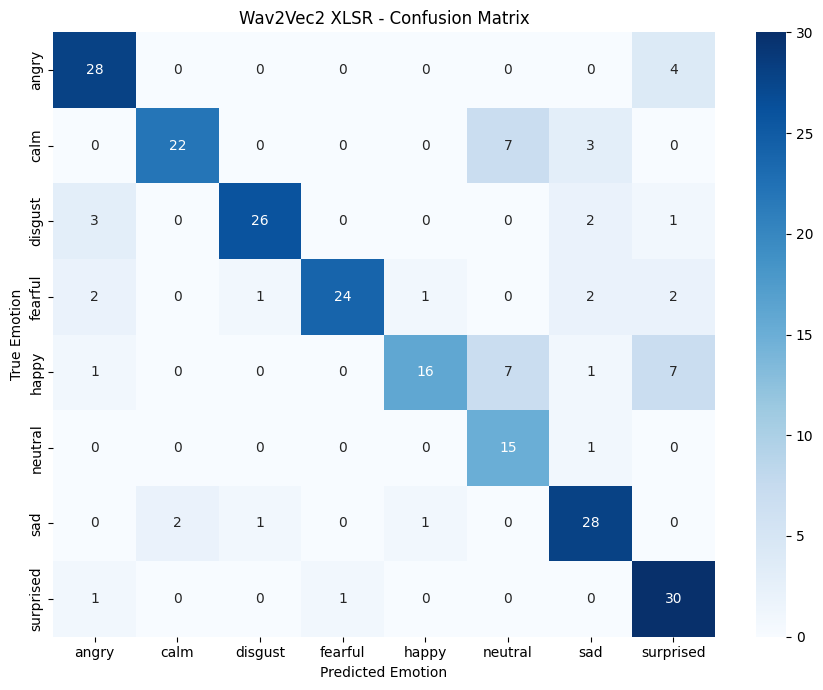

In [62]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(
    xlsr_true_labels,
    xlsr_predictions
)

emotion_names = [
    "angry",
    "calm",
    "disgust",
    "fearful",
    "happy",
    "neutral",
    "sad",
    "surprised"
]

plt.figure(figsize=(9, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=emotion_names,
    yticklabels=emotion_names,
    cmap="Blues"
)

plt.xlabel("Predicted Emotion")
plt.ylabel("True Emotion")
plt.title("Wav2Vec2 XLSR - Confusion Matrix")
plt.tight_layout()
plt.show()

In [63]:
# Save the best XLSR model
xlsr_trainer.save_model("./final_wav2vec2_xlsr_emotion")

# Save feature extractor
feature_extractor_xlsr.save_pretrained("./final_wav2vec2_xlsr_emotion")

print("Best Wav2Vec2 XLSR model saved successfully.")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Best Wav2Vec2 XLSR model saved successfully.


In [64]:
from transformers import (
    Wav2Vec2ForSequenceClassification,
    AutoFeatureExtractor
)

FINAL_MODEL_PATH = "./final_wav2vec2_xlsr_emotion"

final_feature_extractor = AutoFeatureExtractor.from_pretrained(
    FINAL_MODEL_PATH
)

final_model = Wav2Vec2ForSequenceClassification.from_pretrained(
    FINAL_MODEL_PATH
)

print("Final model loaded successfully.")
print("Number of labels:", final_model.config.num_labels)

Loading weights:   0%|          | 0/426 [00:00<?, ?it/s]

Final model loaded successfully.
Number of labels: 8


In [65]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

final_model = final_model.to(device)
final_model.eval()

print("Device:", device)

Device: cuda


In [67]:
import librosa
import torch
import numpy as np

emotion_names = [
    "angry",
    "calm",
    "disgust",
    "fearful",
    "happy",
    "neutral",
    "sad",
    "surprised"
]

def predict_emotion(audio_path):

    # Load audio at 16 kHz
    audio, sr = librosa.load(
        audio_path,
        sr=16000,
        mono=True
    )

    # Process audio
    inputs = final_feature_extractor(
        audio,
        sampling_rate=16000,
        return_tensors="pt"
    )

    # Move input to GPU
    input_values = inputs["input_values"].to(device)

    # Prediction
    with torch.no_grad():
        outputs = final_model(
            input_values=input_values
        )

    # Probabilities
    probabilities = torch.softmax(
        outputs.logits,
        dim=-1
    )

    # Best prediction
    predicted_id = torch.argmax(
        probabilities,
        dim=-1
    ).item()

    confidence = probabilities[0, predicted_id].item()

    predicted_emotion = emotion_names[predicted_id]

    return predicted_emotion, confidence

In [68]:
sample_audio = df.iloc[0]["file_path"]

emotion, confidence = predict_emotion(sample_audio)

print("Audio:", sample_audio)
print("Predicted Emotion:", emotion)
print("Confidence:", f"{confidence * 100:.2f}%")

Audio: /content/drive/MyDrive/RAVDESS/Actor_01/03-01-01-01-01-01-01.wav
Predicted Emotion: neutral
Confidence: 99.98%


In [69]:
# ============================================================
# SPEECH EMOTION RECOGNITION - MODERN UI
# Wav2Vec2 XLSR Large
# ============================================================

!pip install -q gradio

import gradio as gr
import torch
import librosa
import numpy as np
from transformers import (
    Wav2Vec2ForSequenceClassification,
    AutoFeatureExtractor
)

# ------------------------------------------------------------
# 1. MODEL PATH
# ------------------------------------------------------------

FINAL_MODEL_PATH = "./final_wav2vec2_xlsr_emotion"

# ------------------------------------------------------------
# 2. LOAD MODEL
# ------------------------------------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

final_feature_extractor = AutoFeatureExtractor.from_pretrained(
    FINAL_MODEL_PATH
)

final_model = Wav2Vec2ForSequenceClassification.from_pretrained(
    FINAL_MODEL_PATH
)

final_model = final_model.to(device)
final_model.eval()

# ------------------------------------------------------------
# 3. EMOTION LABELS
# ------------------------------------------------------------

emotion_names = [
    "angry",
    "calm",
    "disgust",
    "fearful",
    "happy",
    "neutral",
    "sad",
    "surprised"
]

# ------------------------------------------------------------
# 4. EMOTION ICONS
# ------------------------------------------------------------

emotion_icons = {
    "angry": "Angry",
    "calm": "Calm",
    "disgust": "Disgust",
    "fearful": "Fearful",
    "happy": "Happy",
    "neutral": "Neutral",
    "sad": "Sad",
    "surprised": "Surprised"
}

# ------------------------------------------------------------
# 5. PREDICTION FUNCTION
# ------------------------------------------------------------

def predict_emotion(audio_path):

    if audio_path is None:
        return (
            "No audio uploaded",
            "Please upload a WAV or audio file first.",
            {},
            ""
        )

    try:

        # Load audio
        audio, sr = librosa.load(
            audio_path,
            sr=16000,
            mono=True
        )

        # Check audio
        if len(audio) == 0:
            return (
                "Invalid Audio",
                "The uploaded audio file is empty.",
                {},
                ""
            )

        # Feature extraction
        inputs = final_feature_extractor(
            audio,
            sampling_rate=16000,
            return_tensors="pt"
        )

        input_values = inputs["input_values"].to(device)

        # Model prediction
        with torch.no_grad():

            outputs = final_model(
                input_values=input_values
            )

        # Probabilities
        probabilities = torch.softmax(
            outputs.logits,
            dim=-1
        )[0]

        # Sort probabilities
        sorted_indices = torch.argsort(
            probabilities,
            descending=True
        )

        # Best prediction
        best_index = sorted_indices[0].item()

        predicted_emotion = emotion_names[best_index]

        confidence = probabilities[best_index].item() * 100

        # Top 3 results
        top3 = {}

        for idx in sorted_indices[:3]:
            index = idx.item()
            emotion = emotion_names[index]
            probability = probabilities[index].item()

            top3[emotion] = probability

        # Status text
        status = (
            f"Detected emotion: {predicted_emotion.upper()}"
        )

        confidence_text = (
            f"Confidence: {confidence:.2f}%"
        )

        return (
            status,
            confidence_text,
            top3,
            predicted_emotion
        )

    except Exception as e:

        return (
            "Prediction Error",
            str(e),
            {},
            ""
        )


# ------------------------------------------------------------
# 6. RESET FUNCTION
# ------------------------------------------------------------

def reset_ui():
    return None, "Ready for a new audio file.", "", {}


# ------------------------------------------------------------
# 7. CUSTOM CSS
# ------------------------------------------------------------

custom_css = """

body {
    background: #0b1020 !important;
}

.gradio-container {
    max-width: 1100px !important;
    margin: auto !important;
}

.header-box {
    text-align: center;
    padding: 30px 20px 20px 20px;
}

.title {
    font-size: 38px;
    font-weight: 800;
    letter-spacing: -1px;
    margin-bottom: 8px;
}

.subtitle {
    font-size: 17px;
    opacity: 0.75;
}

.info-card {
    border-radius: 18px;
    padding: 22px;
    border: 1px solid rgba(255,255,255,0.10);
    background: rgba(255,255,255,0.04);
}

.result-card {
    border-radius: 20px;
    padding: 28px;
    min-height: 180px;
    border: 1px solid rgba(255,255,255,0.12);
    background: linear-gradient(
        145deg,
        rgba(255,255,255,0.08),
        rgba(255,255,255,0.025)
    );
}

.result-title {
    font-size: 15px;
    opacity: 0.65;
    text-transform: uppercase;
    letter-spacing: 1px;
}

.result-emotion {
    font-size: 36px;
    font-weight: 800;
    margin-top: 8px;
}

.confidence {
    font-size: 20px;
    margin-top: 10px;
}

.footer {
    text-align: center;
    opacity: 0.55;
    padding: 25px;
    font-size: 13px;
}

button {
    border-radius: 12px !important;
}

"""

# ------------------------------------------------------------
# 8. BUILD UI
# ------------------------------------------------------------

with gr.Blocks(
    theme=gr.themes.Soft(
        primary_hue="blue",
        neutral_hue="slate"
    ),
    css=custom_css,
    title="Speech Emotion Recognition"
) as demo:

    # Header
    gr.HTML("""
    <div class="header-box">
        <div class="title">
            Speech Emotion Recognition
        </div>

        <div class="subtitle">
            AI-powered emotion detection using Wav2Vec2 XLSR Large
        </div>
    </div>
    """)

    # Main area
    with gr.Row():

        # LEFT SIDE
        with gr.Column(scale=1):

            gr.Markdown("### Upload Your Audio")

            audio_input = gr.Audio(
                sources=["upload"],
                type="filepath",
                label="Upload Speech Audio"
            )

            gr.Markdown(
                "Supported audio files: WAV, MP3 and other common formats."
            )

            with gr.Row():

                predict_button = gr.Button(
                    "Predict Emotion",
                    variant="primary",
                    size="lg"
                )

                reset_button = gr.Button(
                    "Reset",
                    variant="secondary",
                    size="lg"
                )

        # RIGHT SIDE
        with gr.Column(scale=1):

            gr.Markdown("### Prediction Result")

            result_status = gr.Markdown(
                "Ready for a new audio file."
            )

            result_confidence = gr.Markdown(
                ""
            )

            predicted_emotion = gr.Textbox(
                label="Predicted Emotion",
                interactive=False
            )

            top3_results = gr.Label(
                num_top_classes=3,
                label="Top 3 Emotion Probabilities"
            )

    # Model information
    gr.Markdown("### Model Information")

    with gr.Row():

        with gr.Column():
            gr.HTML("""
            <div class="info-card">
                <b>Model</b><br>
                Wav2Vec2 XLSR Large
            </div>
            """)

        with gr.Column():
            gr.HTML("""
            <div class="info-card">
                <b>Dataset</b><br>
                RAVDESS Speech
            </div>
            """)

        with gr.Column():
            gr.HTML("""
            <div class="info-card">
                <b>Test Accuracy</b><br>
                78.75%
            </div>
            """)

        with gr.Column():
            gr.HTML("""
            <div class="info-card">
                <b>Emotion Classes</b><br>
                8 Classes
            </div>
            """)

    # Emotion classes
    gr.Markdown("### Supported Emotions")

    gr.Markdown(
        "**Angry · Calm · Disgust · Fearful · Happy · Neutral · Sad · Surprised**"
    )

    # Footer
    gr.HTML("""
    <div class="footer">
        Speech Emotion Recognition • Wav2Vec2 XLSR Large • RAVDESS
    </div>
    """)

    # --------------------------------------------------------
    # BUTTON EVENTS
    # --------------------------------------------------------

    predict_button.click(
        fn=predict_emotion,
        inputs=audio_input,
        outputs=[
            result_status,
            result_confidence,
            top3_results,
            predicted_emotion
        ]
    )

    reset_button.click(
        fn=reset_ui,
        inputs=[],
        outputs=[
            audio_input,
            result_status,
            predicted_emotion,
            top3_results
        ]
    )


# ------------------------------------------------------------
# 9. LAUNCH
# ------------------------------------------------------------

demo.launch(
    share=True,
    debug=True
)

Loading weights:   0%|          | 0/426 [00:00<?, ?it/s]

/tmp/ipykernel_1441/545937368.py:267: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme, css. Please pass these parameters to launch() instead.
  with gr.Blocks(


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://4886831d2887ab5efe.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://4886831d2887ab5efe.gradio.live


In [70]:
# ============================================================
# PREMIUM SPEECH EMOTION RECOGNITION UI
# Wav2Vec2 XLSR Large + RAVDESS
# ============================================================

!pip install -q gradio

import gradio as gr
import torch
import librosa
import numpy as np
import html

# ------------------------------------------------------------
# DEVICE
# ------------------------------------------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

final_model = final_model.to(device)
final_model.eval()

# ------------------------------------------------------------
# EMOTIONS
# ------------------------------------------------------------

emotion_names = [
    "angry",
    "calm",
    "disgust",
    "fearful",
    "happy",
    "neutral",
    "sad",
    "surprised"
]

# ------------------------------------------------------------
# EMOTION COLORS
# ------------------------------------------------------------

emotion_colors = {
    "angry": "#ff4d6d",
    "calm": "#38bdf8",
    "disgust": "#a78bfa",
    "fearful": "#f59e0b",
    "happy": "#facc15",
    "neutral": "#94a3b8",
    "sad": "#60a5fa",
    "surprised": "#22d3ee"
}

# ------------------------------------------------------------
# PREDICTION
# ------------------------------------------------------------

def predict_emotion(audio_path):

    if audio_path is None:
        return (
            """
            <div class="empty-result">
                <div class="empty-icon">🎙</div>
                <div class="empty-title">No Audio Yet</div>
                <div class="empty-text">
                    Upload a speech recording to analyze the emotion.
                </div>
            </div>
            """,
            {},
            "Ready"
        )

    try:

        # Load audio
        audio, sr = librosa.load(
            audio_path,
            sr=16000,
            mono=True
        )

        if len(audio) == 0:
            raise ValueError("The audio file is empty.")

        # Feature extraction
        inputs = final_feature_extractor(
            audio,
            sampling_rate=16000,
            return_tensors="pt"
        )

        input_values = inputs["input_values"].to(device)

        # Prediction
        with torch.no_grad():

            outputs = final_model(
                input_values=input_values
            )

        # Probabilities
        probabilities = torch.softmax(
            outputs.logits,
            dim=-1
        )[0]

        # Sort
        sorted_indices = torch.argsort(
            probabilities,
            descending=True
        )

        best_index = sorted_indices[0].item()

        predicted_emotion = emotion_names[best_index]

        confidence = (
            probabilities[best_index].item() * 100
        )

        # ----------------------------------------------------
        # RESULT CARD
        # ----------------------------------------------------

        main_color = emotion_colors[predicted_emotion]

        result_html = f"""
        <div class="result-card animate-result">

            <div class="result-top">
                <div class="result-label">
                    DETECTED EMOTION
                </div>

                <div class="status-dot"></div>
            </div>

            <div
                class="emotion-name"
                style="color:{main_color};"
            >
                {predicted_emotion.upper()}
            </div>

            <div class="confidence-label">
                Confidence
                <span>{confidence:.2f}%</span>
            </div>

            <div class="confidence-track">
                <div
                    class="confidence-fill"
                    style="
                        width:{confidence:.2f}%;
                        background:linear-gradient(
                            90deg,
                            {main_color},
                            #8b5cf6
                        );
                    "
                ></div>
            </div>

            <div class="result-message">
                The AI model detected
                <b>{predicted_emotion}</b>
                as the most likely emotion in this speech.
            </div>

        </div>
        """

        # ----------------------------------------------------
        # TOP 3
        # ----------------------------------------------------

        top3 = {}

        for idx in sorted_indices[:3]:

            index = idx.item()

            emotion = emotion_names[index]

            probability = probabilities[index].item()

            top3[emotion] = probability

        return (
            result_html,
            top3,
            "Analysis Complete"
        )

    except Exception as e:

        error_html = f"""
        <div class="error-card">
            <div class="error-title">
                Prediction Error
            </div>

            <div class="error-text">
                {html.escape(str(e))}
            </div>
        </div>
        """

        return (
            error_html,
            {},
            "Error"
        )


# ------------------------------------------------------------
# RESET
# ------------------------------------------------------------

def reset_ui():

    return (
        None,
        """
        <div class="empty-result">
            <div class="empty-icon">🎙</div>

            <div class="empty-title">
                Ready for Analysis
            </div>

            <div class="empty-text">
                Upload a speech recording to begin.
            </div>
        </div>
        """,
        {},
        "Ready"
    )


# ============================================================
# PREMIUM CSS
# ============================================================

custom_css = """

/* ==========================================================
   GLOBAL
   ========================================================== */

body {
    margin: 0 !important;
    background:
        radial-gradient(
            circle at 10% 10%,
            rgba(99,102,241,0.22),
            transparent 30%
        ),
        radial-gradient(
            circle at 90% 20%,
            rgba(6,182,212,0.18),
            transparent 30%
        ),
        radial-gradient(
            circle at 50% 100%,
            rgba(139,92,246,0.18),
            transparent 35%
        ),
        #070b18 !important;
}

.gradio-container {
    max-width: 1180px !important;
    margin: auto !important;
    background: transparent !important;
}

/* ==========================================================
   BACKGROUND
   ========================================================== */

#app-wrapper {
    position: relative;
    overflow: hidden;
    padding: 10px 0 35px 0;
}

#app-wrapper::before,
#app-wrapper::after {
    content: "";
    position: absolute;
    width: 260px;
    height: 260px;
    border-radius: 50%;
    filter: blur(80px);
    opacity: 0.22;
    animation: floatBlob 9s ease-in-out infinite alternate;
    pointer-events: none;
}

#app-wrapper::before {
    background: #6366f1;
    top: 60px;
    left: -130px;
}

#app-wrapper::after {
    background: #06b6d4;
    right: -130px;
    bottom: 80px;
    animation-delay: 2s;
}

@keyframes floatBlob {
    0% {
        transform: translateY(0px) scale(1);
    }

    100% {
        transform: translateY(45px) scale(1.15);
    }
}

/* ==========================================================
   HEADER
   ========================================================== */

.hero {
    position: relative;
    text-align: center;
    padding: 48px 20px 35px;
}

.ai-badge {
    display: inline-flex;
    align-items: center;
    gap: 8px;
    padding: 8px 16px;
    border-radius: 999px;

    background: rgba(99,102,241,0.12);
    border: 1px solid rgba(129,140,248,0.35);

    color: #c7d2fe;
    font-size: 12px;
    font-weight: 700;

    letter-spacing: 1.5px;

    animation: badgePulse 3s ease-in-out infinite;
}

@keyframes badgePulse {

    0%, 100% {
        box-shadow: 0 0 0 rgba(99,102,241,0);
    }

    50% {
        box-shadow: 0 0 25px rgba(99,102,241,0.25);
    }
}

.hero-title {
    margin-top: 20px;

    font-size: 48px;
    line-height: 1.05;

    font-weight: 900;

    background:
        linear-gradient(
            90deg,
            #ffffff,
            #a5b4fc,
            #67e8f9,
            #ffffff
        );

    background-size: 250% auto;

    -webkit-background-clip: text;
    background-clip: text;

    color: transparent;

    animation: gradientMove 6s linear infinite;
}

@keyframes gradientMove {

    0% {
        background-position: 0% center;
    }

    100% {
        background-position: 250% center;
    }
}

.hero-subtitle {
    margin-top: 14px;

    color: #94a3b8;

    font-size: 16px;
    line-height: 1.6;
}

/* ==========================================================
   GLASS CARDS
   ========================================================== */

.glass-card {
    border-radius: 24px !important;

    background:
        linear-gradient(
            145deg,
            rgba(255,255,255,0.075),
            rgba(255,255,255,0.025)
        ) !important;

    border: 1px solid rgba(255,255,255,0.10) !important;

    box-shadow:
        0 20px 60px rgba(0,0,0,0.25),
        inset 0 1px 0 rgba(255,255,255,0.05);

    backdrop-filter: blur(18px);

    padding: 25px !important;

    transition:
        transform 0.3s ease,
        border-color 0.3s ease,
        box-shadow 0.3s ease;
}

.glass-card:hover {
    transform: translateY(-4px);

    border-color:
        rgba(129,140,248,0.35) !important;

    box-shadow:
        0 25px 70px rgba(0,0,0,0.35),
        0 0 40px rgba(99,102,241,0.08);
}

/* ==========================================================
   SECTION HEADINGS
   ========================================================== */

.section-title {
    color: #f8fafc;

    font-size: 18px;
    font-weight: 800;

    margin-bottom: 5px;
}

.section-description {
    color: #64748b;

    font-size: 13px;

    margin-bottom: 20px;
}

/* ==========================================================
   AUDIO UPLOAD
   ========================================================== */

.audio-upload {
    border: 1px dashed rgba(129,140,248,0.45) !important;

    border-radius: 18px !important;

    background:
        rgba(99,102,241,0.035) !important;

    transition: all 0.3s ease;
}

.audio-upload:hover {
    border-color: #818cf8 !important;

    background:
        rgba(99,102,241,0.08) !important;

    transform: scale(1.01);
}

/* ==========================================================
   BUTTONS
   ========================================================== */

.predict-btn {
    min-height: 54px !important;

    border-radius: 15px !important;

    border: none !important;

    background:
        linear-gradient(
            135deg,
            #6366f1,
            #8b5cf6,
            #06b6d4
        ) !important;

    color: white !important;

    font-size: 16px !important;

    font-weight: 800 !important;

    box-shadow:
        0 10px 30px rgba(99,102,241,0.25);

    transition:
        transform 0.25s ease,
        box-shadow 0.25s ease;
}

.predict-btn:hover {
    transform: translateY(-3px);

    box-shadow:
        0 15px 40px rgba(99,102,241,0.4);
}

.predict-btn:active {
    transform: scale(0.98);
}

.reset-btn {
    min-height: 54px !important;

    border-radius: 15px !important;

    background:
        rgba(255,255,255,0.05) !important;

    border:
        1px solid rgba(255,255,255,0.12) !important;

    color: #cbd5e1 !important;

    transition: all 0.25s ease;
}

.reset-btn:hover {
    background:
        rgba(255,255,255,0.10) !important;

    transform: translateY(-2px);
}

/* ==========================================================
   RESULT
   ========================================================== */

.result-card {
    border-radius: 22px;

    padding: 28px;

    background:
        linear-gradient(
            145deg,
            rgba(99,102,241,0.10),
            rgba(6,182,212,0.035)
        );

    border:
        1px solid rgba(129,140,248,0.20);

    min-height: 240px;
}

.animate-result {
    animation: resultAppear 0.65s ease forwards;
}

@keyframes resultAppear {

    0% {
        opacity: 0;
        transform: translateY(15px) scale(0.97);
    }

    100% {
        opacity: 1;
        transform: translateY(0) scale(1);
    }
}

.result-top {
    display: flex;

    justify-content: space-between;

    align-items: center;
}

.result-label {
    color: #94a3b8;

    font-size: 11px;

    font-weight: 800;

    letter-spacing: 2px;
}

.status-dot {
    width: 10px;
    height: 10px;

    border-radius: 50%;

    background: #22c55e;

    box-shadow:
        0 0 15px rgba(34,197,94,0.7);

    animation: dotPulse 1.5s infinite;
}

@keyframes dotPulse {

    0%, 100% {
        transform: scale(1);
        opacity: 1;
    }

    50% {
        transform: scale(1.35);
        opacity: 0.6;
    }
}

.emotion-name {
    margin-top: 20px;

    font-size: 44px;

    font-weight: 900;

    letter-spacing: -1px;
}

.confidence-label {
    margin-top: 22px;

    display: flex;

    justify-content: space-between;

    color: #94a3b8;

    font-size: 13px;
}

.confidence-label span {
    color: #f8fafc;

    font-weight: 800;
}

.confidence-track {
    height: 9px;

    margin-top: 10px;

    border-radius: 999px;

    background: rgba(255,255,255,0.07);

    overflow: hidden;
}

.confidence-fill {
    height: 100%;

    border-radius: 999px;

    animation: confidenceGrow 1.2s ease-out;
}

@keyframes confidenceGrow {

    0% {
        width: 0 !important;
    }
}

.result-message {
    margin-top: 20px;

    color: #94a3b8;

    font-size: 13px;

    line-height: 1.6;
}

/* ==========================================================
   EMPTY RESULT
   ========================================================== */

.empty-result {
    min-height: 240px;

    display: flex;

    flex-direction: column;

    justify-content: center;

    align-items: center;

    text-align: center;

    border-radius: 22px;

    background:
        rgba(255,255,255,0.025);

    border:
        1px dashed rgba(255,255,255,0.10);
}

.empty-icon {
    font-size: 42px;

    margin-bottom: 12px;

    animation: microphoneFloat 3s ease-in-out infinite;
}

@keyframes microphoneFloat {

    0%, 100% {
        transform: translateY(0);
    }

    50% {
        transform: translateY(-8px);
    }
}

.empty-title {
    color: #e2e8f0;

    font-size: 18px;

    font-weight: 800;
}

.empty-text {
    color: #64748b;

    font-size: 13px;

    margin-top: 7px;
}

/* ==========================================================
   ERROR
   ========================================================== */

.error-card {
    padding: 25px;

    border-radius: 18px;

    background:
        rgba(239,68,68,0.08);

    border:
        1px solid rgba(239,68,68,0.25);
}

.error-title {
    color: #fca5a5;

    font-weight: 800;

    font-size: 18px;
}

.error-text {
    color: #94a3b8;

    margin-top: 8px;

    font-size: 13px;
}

/* ==========================================================
   INFO CARDS
   ========================================================== */

.metric-card {
    padding: 20px;

    border-radius: 18px;

    background:
        rgba(255,255,255,0.035);

    border:
        1px solid rgba(255,255,255,0.08);

    transition: all 0.25s ease;
}

.metric-card:hover {
    transform: translateY(-3px);

    background:
        rgba(255,255,255,0.06);

    border-color:
        rgba(129,140,248,0.25);
}

.metric-value {
    color: #f8fafc;

    font-size: 22px;

    font-weight: 900;
}

.metric-label {
    color: #64748b;

    font-size: 11px;

    text-transform: uppercase;

    letter-spacing: 1px;

    margin-top: 5px;
}

/* ==========================================================
   FOOTER
   ========================================================== */

.footer {
    text-align: center;

    color: #475569;

    font-size: 12px;

    padding: 25px 0 5px;
}

/* ==========================================================
   MOBILE
   ========================================================== */

@media (max-width: 700px) {

    .hero-title {
        font-size: 34px;
    }

    .hero {
        padding-top: 30px;
    }

    .emotion-name {
        font-size: 36px;
    }
}

"""


# ============================================================
# BUILD UI
# ============================================================

with gr.Blocks(
    theme=gr.themes.Base(
        primary_hue="indigo",
        neutral_hue="slate",
        font=[
            gr.themes.GoogleFont("Inter"),
            "Arial",
            "sans-serif"
        ]
    ),
    css=custom_css,
    title="Speech Emotion AI"
) as demo:

    with gr.Column(elem_id="app-wrapper"):

        # ----------------------------------------------------
        # HERO
        # ----------------------------------------------------

        gr.HTML("""
        <div class="hero">

            <div class="ai-badge">
                ● AI POWERED SPEECH ANALYSIS
            </div>

            <div class="hero-title">
                Speech Emotion AI
            </div>

            <div class="hero-subtitle">
                Detect human emotions from speech using
                <b>Wav2Vec2 XLSR Large</b>
            </div>

        </div>
        """)

        # ----------------------------------------------------
        # MAIN
        # ----------------------------------------------------

        with gr.Row():

            # =================================================
            # LEFT
            # =================================================

            with gr.Column(
                scale=1,
                elem_classes=["glass-card"]
            ):

                gr.HTML("""
                <div class="section-title">
                    Upload Speech
                </div>

                <div class="section-description">
                    Upload an audio recording and let the AI
                    analyze the speaker's emotional state.
                </div>
                """)

                audio_input = gr.Audio(
                    sources=["upload"],
                    type="filepath",
                    label="Audio Recording",
                    elem_classes=["audio-upload"]
                )

                gr.Markdown(
                    "Supports WAV, MP3 and common audio formats."
                )

                with gr.Row():

                    predict_button = gr.Button(
                        "Analyze Emotion",
                        variant="primary",
                        size="lg",
                        elem_classes=["predict-btn"]
                    )

                    reset_button = gr.Button(
                        "Reset",
                        size="lg",
                        elem_classes=["reset-btn"]
                    )

            # =================================================
            # RIGHT
            # =================================================

            with gr.Column(
                scale=1,
                elem_classes=["glass-card"]
            ):

                gr.HTML("""
                <div class="section-title">
                    AI Analysis
                </div>

                <div class="section-description">
                    Real-time emotion classification results.
                </div>
                """)

                result_output = gr.HTML(
                    """
                    <div class="empty-result">

                        <div class="empty-icon">
                            🎙
                        </div>

                        <div class="empty-title">
                            Ready for Analysis
                        </div>

                        <div class="empty-text">
                            Upload a speech recording to begin.
                        </div>

                    </div>
                    """
                )

                status_output = gr.Textbox(
                    value="Ready",
                    label="System Status",
                    interactive=False
                )

        # ----------------------------------------------------
        # TOP 3
        # ----------------------------------------------------

        gr.HTML("""
        <div style="
            margin-top:28px;
            margin-bottom:12px;
            color:#f8fafc;
            font-size:18px;
            font-weight:800;
        ">
            Emotion Probability Analysis
        </div>

        <div style="
            color:#64748b;
            font-size:13px;
            margin-bottom:15px;
        ">
            Top predicted emotions from the model.
        </div>
        """)

        top3_output = gr.Label(
            num_top_classes=3,
            label="Top 3 Predictions"
        )

        # ----------------------------------------------------
        # MODEL STATS
        # ----------------------------------------------------

        gr.HTML("""
        <div style="
            margin-top:28px;
            margin-bottom:15px;
            color:#f8fafc;
            font-size:18px;
            font-weight:800;
        ">
            Model Overview
        </div>
        """)

        with gr.Row():

            gr.HTML("""
            <div class="metric-card">
                <div class="metric-value">
                    78.75%
                </div>
                <div class="metric-label">
                    Test Accuracy
                </div>
            </div>
            """)

            gr.HTML("""
            <div class="metric-card">
                <div class="metric-value">
                    78.73%
                </div>
                <div class="metric-label">
                    F1 Score
                </div>
            </div>
            """)

            gr.HTML("""
            <div class="metric-card">
                <div class="metric-value">
                    8
                </div>
                <div class="metric-label">
                    Emotion Classes
                </div>
            </div>
            """)

            gr.HTML("""
            <div class="metric-card">
                <div class="metric-value">
                    XLSR
                </div>
                <div class="metric-label">
                    AI Architecture
                </div>
            </div>
            """)

        # ----------------------------------------------------
        # EMOTIONS
        # ----------------------------------------------------

        gr.HTML("""
        <div style="
            margin-top:28px;
            margin-bottom:12px;
            color:#f8fafc;
            font-size:18px;
            font-weight:800;
        ">
            Supported Emotions
        </div>

        <div style="
            color:#94a3b8;
            font-size:13px;
            line-height:2;
        ">
            Angry &nbsp; • &nbsp;
            Calm &nbsp; • &nbsp;
            Disgust &nbsp; • &nbsp;
            Fearful &nbsp; • &nbsp;
            Happy &nbsp; • &nbsp;
            Neutral &nbsp; • &nbsp;
            Sad &nbsp; • &nbsp;
            Surprised
        </div>
        """)

        # ----------------------------------------------------
        # FOOTER
        # ----------------------------------------------------

        gr.HTML("""
        <div class="footer">
            Speech Emotion Recognition
            &nbsp;•&nbsp;
            RAVDESS Dataset
            &nbsp;•&nbsp;
            Wav2Vec2 XLSR Large
        </div>
        """)

        # ====================================================
        # EVENTS
        # ====================================================

        predict_button.click(
            fn=predict_emotion,
            inputs=audio_input,
            outputs=[
                result_output,
                top3_output,
                status_output
            ]
        )

        reset_button.click(
            fn=reset_ui,
            inputs=[],
            outputs=[
                audio_input,
                result_output,
                top3_output,
                status_output
            ]
        )


# ============================================================
# LAUNCH
# ============================================================

demo.launch(
    share=True,
    debug=True
)

/tmp/ipykernel_1441/3507473823.py:898: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme, css. Please pass these parameters to launch() instead.
  with gr.Blocks(


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://adf0277285e3205517.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://adf0277285e3205517.gradio.live


In [ ]:
# ============================================================
# PREMIUM DARK AI SPEECH EMOTION UI
# Wav2Vec2 XLSR Large
# ============================================================

!pip install -q gradio

import gradio as gr
import torch
import librosa
import numpy as np
import html

# ============================================================
# DEVICE
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

final_model = final_model.to(device)
final_model.eval()

# ============================================================
# EMOTIONS
# ============================================================

emotion_names = [
    "angry",
    "calm",
    "disgust",
    "fearful",
    "happy",
    "neutral",
    "sad",
    "surprised"
]

emotion_colors = {
    "angry": "#ff4d6d",
    "calm": "#38bdf8",
    "disgust": "#a78bfa",
    "fearful": "#f59e0b",
    "happy": "#facc15",
    "neutral": "#94a3b8",
    "sad": "#60a5fa",
    "surprised": "#22d3ee"
}

# ============================================================
# PREDICTION
# ============================================================

def predict_emotion(audio_path):

    if audio_path is None:
        return (
            """
            <div class="empty-result">
                <div class="mic-circle">🎙</div>
                <div class="empty-title">Waiting for Audio</div>
                <div class="empty-text">
                    Upload a speech recording to start emotion analysis.
                </div>
            </div>
            """,
            {},
            "READY"
        )

    try:

        audio, sr = librosa.load(
            audio_path,
            sr=16000,
            mono=True
        )

        if len(audio) == 0:
            raise ValueError("The uploaded audio file is empty.")

        inputs = final_feature_extractor(
            audio,
            sampling_rate=16000,
            return_tensors="pt"
        )

        input_values = inputs["input_values"].to(device)

        with torch.no_grad():

            outputs = final_model(
                input_values=input_values
            )

        probabilities = torch.softmax(
            outputs.logits,
            dim=-1
        )[0]

        sorted_indices = torch.argsort(
            probabilities,
            descending=True
        )

        best_index = sorted_indices[0].item()

        predicted_emotion = emotion_names[best_index]

        confidence = (
            probabilities[best_index].item() * 100
        )

        main_color = emotion_colors[predicted_emotion]

        # ----------------------------------------------------
        # RESULT CARD
        # ----------------------------------------------------

        result_html = f"""
        <div class="result-card">

            <div class="result-header">

                <div>
                    <div class="result-label">
                        AI DETECTION RESULT
                    </div>

                    <div class="result-small">
                        Wav2Vec2 XLSR Large
                    </div>
                </div>

                <div class="live-badge">
                    <span class="live-dot"></span>
                    ANALYZED
                </div>

            </div>

            <div
                class="emotion-name"
                style="color:{main_color};"
            >
                {predicted_emotion.upper()}
            </div>

            <div class="confidence-row">

                <span>Confidence</span>

                <strong>
                    {confidence:.2f}%
                </strong>

            </div>

            <div class="confidence-track">

                <div
                    class="confidence-fill"
                    style="
                        width:{confidence:.2f}%;
                        background:
                        linear-gradient(
                            90deg,
                            {main_color},
                            #8b5cf6,
                            #06b6d4
                        );
                    "
                ></div>

            </div>

            <div class="result-description">

                The AI model identified
                <strong>{predicted_emotion}</strong>
                as the most likely emotional state
                expressed in the uploaded speech.

            </div>

        </div>
        """

        # ----------------------------------------------------
        # TOP 3
        # ----------------------------------------------------

        top3 = {}

        for idx in sorted_indices[:3]:

            index = idx.item()

            emotion = emotion_names[index]

            probability = probabilities[index].item()

            top3[emotion] = probability

        return (
            result_html,
            top3,
            "ANALYSIS COMPLETE"
        )

    except Exception as e:

        return (
            f"""
            <div class="error-card">
                <div class="error-title">
                    Prediction Error
                </div>

                <div class="error-text">
                    {html.escape(str(e))}
                </div>
            </div>
            """,
            {},
            "ERROR"
        )


# ============================================================
# RESET
# ============================================================

def reset_ui():

    return (
        None,

        """
        <div class="empty-result">

            <div class="mic-circle">
                🎙
            </div>

            <div class="empty-title">
                Waiting for Audio
            </div>

            <div class="empty-text">
                Upload a speech recording to start emotion analysis.
            </div>

        </div>
        """,

        {},

        "READY"
    )


# ============================================================
# PREMIUM DARK CSS
# ============================================================

custom_css = """

/* ============================================================
   GLOBAL DARK THEME
   ============================================================ */

html,
body {
    background:
        #050816 !important;

    color:
        #e5e7eb !important;
}

body {
    margin: 0 !important;
}

.gradio-container {
    max-width: 1180px !important;
    margin: auto !important;

    background:
        #050816 !important;

    color:
        #e5e7eb !important;
}


/* Remove Gradio white surfaces */

.gradio-container *,
.gradio-container .block,
.gradio-container .form,
.gradio-container .panel,
.gradio-container .gr-box,
.gradio-container .gr-group,
.gradio-container .gr-panel {
    color: #e5e7eb;
}


/* ============================================================
   MAIN BACKGROUND
   ============================================================ */

#app-wrapper {

    position: relative;

    overflow: hidden;

    padding:
        10px 10px 40px;

    background:
        radial-gradient(
            circle at 10% 15%,
            rgba(79,70,229,0.22),
            transparent 28%
        ),

        radial-gradient(
            circle at 90% 10%,
            rgba(6,182,212,0.18),
            transparent 27%
        ),

        radial-gradient(
            circle at 50% 100%,
            rgba(139,92,246,0.16),
            transparent 32%
        ),

        #050816 !important;

}


/* Animated glow */

#app-wrapper::before {

    content: "";

    position: absolute;

    width: 300px;
    height: 300px;

    left: -130px;
    top: 250px;

    border-radius: 50%;

    background:
        #4f46e5;

    opacity: 0.12;

    filter:
        blur(100px);

    animation:
        floatGlow 8s ease-in-out infinite alternate;

    pointer-events: none;
}


#app-wrapper::after {

    content: "";

    position: absolute;

    width: 300px;
    height: 300px;

    right: -130px;
    bottom: 150px;

    border-radius: 50%;

    background:
        #06b6d4;

    opacity: 0.10;

    filter:
        blur(100px);

    animation:
        floatGlow 10s ease-in-out infinite alternate-reverse;

    pointer-events: none;
}


@keyframes floatGlow {

    0% {
        transform: translateY(0) scale(1);
    }

    100% {
        transform: translateY(45px) scale(1.2);
    }

}


/* ============================================================
   HERO
   ============================================================ */

.hero {

    position: relative;

    text-align: center;

    padding:
        55px 20px 40px;

}


.ai-badge {

    display: inline-flex;

    align-items: center;

    gap: 9px;

    padding:
        9px 17px;

    border-radius:
        999px;

    background:
        rgba(79,70,229,0.12) !important;

    border:
        1px solid rgba(129,140,248,0.30);

    color:
        #a5b4fc !important;

    font-size:
        11px;

    font-weight:
        800;

    letter-spacing:
        1.8px;

    box-shadow:
        0 0 25px rgba(99,102,241,0.08);

}


.ai-badge::before {

    content: "";

    width: 7px;
    height: 7px;

    border-radius: 50%;

    background:
        #22d3ee;

    box-shadow:
        0 0 12px #22d3ee;

    animation:
        pulseDot 1.5s infinite;

}


@keyframes pulseDot {

    0%,100% {
        opacity: 1;
        transform: scale(1);
    }

    50% {
        opacity: .45;
        transform: scale(.7);
    }

}


.hero-title {

    margin-top:
        22px;

    font-size:
        52px;

    line-height:
        1.05;

    font-weight:
        900;

    letter-spacing:
        -2px;

    background:
        linear-gradient(
            90deg,
            #ffffff,
            #a5b4fc,
            #67e8f9,
            #c4b5fd,
            #ffffff
        );

    background-size:
        300% auto;

    -webkit-background-clip:
        text;

    background-clip:
        text;

    color:
        transparent !important;

    animation:
        gradientFlow 7s linear infinite;

}


@keyframes gradientFlow {

    0% {
        background-position: 0% center;
    }

    100% {
        background-position: 300% center;
    }

}


.hero-subtitle {

    margin-top:
        16px;

    color:
        #94a3b8 !important;

    font-size:
        16px;

    line-height:
        1.7;

}


.hero-subtitle b {

    color:
        #c4b5fd !important;

}


/* ============================================================
   GLASS CARDS
   ============================================================ */

.glass-card {

    position: relative;

    border-radius:
        25px !important;

    padding:
        28px !important;

    background:
        linear-gradient(
            145deg,
            rgba(20,27,52,0.90),
            rgba(10,15,31,0.92)
        ) !important;

    border:
        1px solid rgba(129,140,248,0.16) !important;

    box-shadow:
        0 25px 70px rgba(0,0,0,0.35),
        inset 0 1px 0 rgba(255,255,255,0.035) !important;

    backdrop-filter:
        blur(20px);

    transition:
        all .3s ease;

}


.glass-card:hover {

    transform:
        translateY(-4px);

    border-color:
        rgba(129,140,248,0.35) !important;

    box-shadow:
        0 30px 80px rgba(0,0,0,0.42),
        0 0 40px rgba(99,102,241,0.06) !important;

}


/* ============================================================
   SECTION HEADINGS
   ============================================================ */

.section-title {

    color:
        #f8fafc !important;

    font-size:
        19px;

    font-weight:
        800;

}


.section-description {

    color:
        #64748b !important;

    font-size:
        13px;

    line-height:
        1.6;

    margin:
        6px 0 20px;

}


/* ============================================================
   AUDIO COMPONENT
   ============================================================ */

.audio-upload,
.audio-upload *,
.audio-upload .wrap {

    background:
        #0b1226 !important;

}


.audio-upload {

    border:
        1px dashed rgba(99,102,241,0.45) !important;

    border-radius:
        18px !important;

    min-height:
        190px;

    transition:
        all .3s ease;

}


.audio-upload:hover {

    border-color:
        #818cf8 !important;

    background:
        #0e1730 !important;

    box-shadow:
        0 0 30px rgba(99,102,241,0.10);

}


/* ============================================================
   ALL INPUTS DARK
   ============================================================ */

input,
textarea,
select {

    background:
        #0b1226 !important;

    color:
        #e2e8f0 !important;

    border-color:
        rgba(148,163,184,0.15) !important;

}


label {

    color:
        #cbd5e1 !important;

}


/* ============================================================
   BUTTONS
   ============================================================ */

.predict-btn {

    min-height:
        56px !important;

    border-radius:
        15px !important;

    border:
        0 !important;

    background:
        linear-gradient(
            135deg,
            #4f46e5,
            #7c3aed,
            #0891b2
        ) !important;

    color:
        #ffffff !important;

    font-size:
        15px !important;

    font-weight:
        800 !important;

    box-shadow:
        0 12px 35px rgba(79,70,229,0.28) !important;

    transition:
        all .25s ease;

}


.predict-btn:hover {

    transform:
        translateY(-3px);

    box-shadow:
        0 18px 45px rgba(79,70,229,0.42) !important;

}


.reset-btn {

    min-height:
        56px !important;

    border-radius:
        15px !important;

    background:
        #11182d !important;

    border:
        1px solid rgba(148,163,184,0.16) !important;

    color:
        #cbd5e1 !important;

}


.reset-btn:hover {

    background:
        #17213b !important;

    border-color:
        rgba(129,140,248,0.30) !important;

}


/* ============================================================
   RESULT CARD
   ============================================================ */

.result-card {

    min-height:
        250px;

    padding:
        28px;

    border-radius:
        22px;

    background:
        linear-gradient(
            145deg,
            rgba(15,23,52,0.98),
            rgba(9,14,30,0.98)
        );

    border:
        1px solid rgba(129,140,248,0.18);

    animation:
        resultIn .55s ease;

}


@keyframes resultIn {

    from {
        opacity: 0;
        transform: translateY(14px) scale(.98);
    }

    to {
        opacity: 1;
        transform: translateY(0) scale(1);
    }

}


.result-header {

    display:
        flex;

    justify-content:
        space-between;

    align-items:
        flex-start;

}


.result-label {

    color:
        #64748b;

    font-size:
        10px;

    font-weight:
        900;

    letter-spacing:
        2px;

}


.result-small {

    color:
        #475569;

    font-size:
        11px;

    margin-top:
        5px;

}


.live-badge {

    display:
        flex;

    align-items:
        center;

    gap:
        7px;

    padding:
        6px 10px;

    border-radius:
        999px;

    background:
        rgba(34,197,94,0.08);

    border:
        1px solid rgba(34,197,94,0.18);

    color:
        #86efac;

    font-size:
        9px;

    font-weight:
        800;

    letter-spacing:
        1px;

}


.live-dot {

    width:
        6px;

    height:
        6px;

    border-radius:
        50%;

    background:
        #22c55e;

    box-shadow:
        0 0 10px #22c55e;

}


.emotion-name {

    margin-top:
        23px;

    font-size:
        46px;

    font-weight:
        900;

    letter-spacing:
        -1px;

}


.confidence-row {

    margin-top:
        20px;

    display:
        flex;

    justify-content:
        space-between;

    color:
        #64748b;

    font-size:
        13px;

}


.confidence-row strong {

    color:
        #f8fafc;

}


.confidence-track {

    height:
        9px;

    margin-top:
        9px;

    background:
        #11182d;

    border-radius:
        999px;

    overflow:
        hidden;

}


.confidence-fill {

    height:
        100%;

    border-radius:
        999px;

    animation:
        confidenceIn 1s ease;

}


@keyframes confidenceIn {

    from {
        width: 0 !important;
    }

}


.result-description {

    margin-top:
        20px;

    color:
        #64748b;

    font-size:
        12px;

    line-height:
        1.7;

}


.result-description strong {

    color:
        #cbd5e1;

}


/* ============================================================
   EMPTY STATE
   ============================================================ */

.empty-result {

    min-height:
        250px;

    display:
        flex;

    flex-direction:
        column;

    align-items:
        center;

    justify-content:
        center;

    text-align:
        center;

    border-radius:
        22px;

    background:
        #090f20;

    border:
        1px dashed rgba(129,140,248,0.16);

}


.mic-circle {

    width:
        68px;

    height:
        68px;

    display:
        flex;

    align-items:
        center;

    justify-content:
        center;

    border-radius:
        50%;

    background:
        linear-gradient(
            145deg,
            #161e42,
            #0d1430
        );

    border:
        1px solid rgba(129,140,248,0.20);

    font-size:
        28px;

    box-shadow:
        0 0 35px rgba(99,102,241,0.12);

    animation:
        micFloat 3s ease-in-out infinite;

}


@keyframes micFloat {

    0%,100% {
        transform: translateY(0);
    }

    50% {
        transform: translateY(-7px);
    }

}


.empty-title {

    margin-top:
        15px;

    color:
        #e2e8f0;

    font-size:
        17px;

    font-weight:
        800;

}


.empty-text {

    margin-top:
        7px;

    color:
        #475569;

    font-size:
        12px;

}


/* ============================================================
   TOP 3 LABEL COMPONENT
   ============================================================ */

.gradio-container .label-wrap,
.gradio-container .gr-label {

    background:
        #0b1226 !important;

    color:
        #e2e8f0 !important;

}


.gradio-container .label-wrap {

    border:
        1px solid rgba(129,140,248,0.14) !important;

    border-radius:
        18px !important;

}


.gradio-container .label-wrap *,
.gradio-container .gr-label * {

    color:
        #cbd5e1 !important;

}


/* ============================================================
   MARKDOWN
   ============================================================ */

.gradio-container .prose,
.gradio-container .markdown {

    color:
        #cbd5e1 !important;

}


.gradio-container .prose p,
.gradio-container .markdown p {

    color:
        #64748b !important;

}


/* ============================================================
   ERROR
   ============================================================ */

.error-card {

    padding:
        25px;

    border-radius:
        18px;

    background:
        rgba(127,29,29,0.18);

    border:
        1px solid rgba(248,113,113,0.25);

}


.error-title {

    color:
        #fca5a5;

    font-size:
        17px;

    font-weight:
        800;

}


.error-text {

    margin-top:
        8px;

    color:
        #94a3b8;

    font-size:
        12px;

}


/* ============================================================
   MODEL STAT CARDS
   ============================================================ */

.metric-card {

    padding:
        20px;

    border-radius:
        18px;

    background:
        linear-gradient(
            145deg,
            #101831,
            #0a1022
        );

    border:
        1px solid rgba(129,140,248,0.12);

    transition:
        all .25s ease;

}


.metric-card:hover {

    transform:
        translateY(-4px);

    border-color:
        rgba(129,140,248,0.30);

    box-shadow:
        0 15px 35px rgba(0,0,0,0.25);

}


.metric-value {

    color:
        #f8fafc;

    font-size:
        23px;

    font-weight:
        900;

}


.metric-label {

    margin-top:
        5px;

    color:
        #64748b;

    font-size:
        10px;

    font-weight:
        700;

    letter-spacing:
        1px;

    text-transform:
        uppercase;

}


/* ============================================================
   FOOTER
   ============================================================ */

.footer {

    text-align:
        center;

    padding:
        30px 0 5px;

    color:
        #334155;

    font-size:
        11px;

}


/* ============================================================
   MOBILE
   ============================================================ */

@media (max-width: 700px) {

    .hero-title {
        font-size: 36px;
    }

    .hero {
        padding-top: 35px;
    }

    .emotion-name {
        font-size: 36px;
    }

    .glass-card {
        padding: 20px !important;
    }

}

"""


# ============================================================
# BUILD UI
# ============================================================

with gr.Blocks(
    theme=gr.themes.Base(
        primary_hue="indigo",
        secondary_hue="cyan",
        neutral_hue="slate"
    ),
    css=custom_css,
    title="Speech Emotion AI"
) as demo:

    with gr.Column(elem_id="app-wrapper"):

        # ====================================================
        # HERO
        # ====================================================

        gr.HTML("""
        <div class="hero">

            <div class="ai-badge">
                AI POWERED SPEECH ANALYSIS
            </div>

            <div class="hero-title">
                Speech Emotion AI
            </div>

            <div class="hero-subtitle">
                Understand emotions hidden inside human speech
                using <b>Wav2Vec2 XLSR Large</b>
            </div>

        </div>
        """)

        # ====================================================
        # MAIN CARDS
        # ====================================================

        with gr.Row():

            # ------------------------------------------------
            # UPLOAD
            # ------------------------------------------------

            with gr.Column(
                scale=1,
                elem_classes=["glass-card"]
            ):

                gr.HTML("""
                <div class="section-title">
                    Upload Speech
                </div>

                <div class="section-description">
                    Upload an audio recording and let the
                    AI analyze its emotional characteristics.
                </div>
                """)

                audio_input = gr.Audio(
                    sources=["upload"],
                    type="filepath",
                    label="Audio Recording",
                    elem_classes=["audio-upload"]
                )

                gr.Markdown(
                    "WAV, MP3 and other common audio formats are supported."
                )

                with gr.Row():

                    predict_button = gr.Button(
                        "Analyze Emotion",
                        variant="primary",
                        size="lg",
                        elem_classes=["predict-btn"]
                    )

                    reset_button = gr.Button(
                        "Reset",
                        size="lg",
                        elem_classes=["reset-btn"]
                    )


            # ------------------------------------------------
            # RESULT
            # ------------------------------------------------

            with gr.Column(
                scale=1,
                elem_classes=["glass-card"]
            ):

                gr.HTML("""
                <div class="section-title">
                    AI Analysis
                </div>

                <div class="section-description">
                    Real-time speech emotion classification.
                </div>
                """)

                result_output = gr.HTML(
                    """
                    <div class="empty-result">

                        <div class="mic-circle">
                            🎙
                        </div>

                        <div class="empty-title">
                            Waiting for Audio
                        </div>

                        <div class="empty-text">
                            Upload a speech recording to start emotion analysis.
                        </div>

                    </div>
                    """
                )

                status_output = gr.Textbox(
                    value="READY",
                    label="System Status",
                    interactive=False
                )


        # ====================================================
        # TOP 3
        # ====================================================

        gr.HTML("""
        <div style="
            margin-top:32px;
            margin-bottom:8px;
            color:#f8fafc;
            font-size:19px;
            font-weight:800;
        ">
            Emotion Probability
        </div>

        <div style="
            color:#64748b;
            font-size:13px;
            margin-bottom:15px;
        ">
            The three most probable emotions detected by the model.
        </div>
        """)

        top3_output = gr.Label(
            num_top_classes=3,
            label="Top 3 Predictions"
        )


        # ====================================================
        # MODEL OVERVIEW
        # ====================================================

        gr.HTML("""
        <div style="
            margin-top:32px;
            margin-bottom:15px;
            color:#f8fafc;
            font-size:19px;
            font-weight:800;
        ">
            Model Overview
        </div>
        """)

        with gr.Row():

            gr.HTML("""
            <div class="metric-card">
                <div class="metric-value">
                    78.75%
                </div>
                <div class="metric-label">
                    Test Accuracy
                </div>
            </div>
            """)

            gr.HTML("""
            <div class="metric-card">
                <div class="metric-value">
                    78.73%
                </div>
                <div class="metric-label">
                    F1 Score
                </div>
            </div>
            """)

            gr.HTML("""
            <div class="metric-card">
                <div class="metric-value">
                    8
                </div>
                <div class="metric-label">
                    Emotion Classes
                </div>
            </div>
            """)

            gr.HTML("""
            <div class="metric-card">
                <div class="metric-value">
                    XLSR
                </div>
                <div class="metric-label">
                    Architecture
                </div>
            </div>
            """)


        # ====================================================
        # EMOTIONS
        # ====================================================

        gr.HTML("""
        <div style="
            margin-top:32px;
            margin-bottom:12px;
            color:#f8fafc;
            font-size:19px;
            font-weight:800;
        ">
            Supported Emotions
        </div>

        <div style="
            padding:18px 20px;
            border-radius:18px;
            background:#0b1226;
            border:1px solid rgba(129,140,248,0.12);
            color:#94a3b8;
            font-size:13px;
            line-height:2;
        ">
            Angry &nbsp; • &nbsp;
            Calm &nbsp; • &nbsp;
            Disgust &nbsp; • &nbsp;
            Fearful &nbsp; • &nbsp;
            Happy &nbsp; • &nbsp;
            Neutral &nbsp; • &nbsp;
            Sad &nbsp; • &nbsp;
            Surprised
        </div>
        """)


        # ====================================================
        # FOOTER
        # ====================================================

        gr.HTML("""
        <div class="footer">
            Speech Emotion AI
            &nbsp; • &nbsp;
            RAVDESS
            &nbsp; • &nbsp;
            Wav2Vec2 XLSR Large
            &nbsp; • &nbsp;
            Deep Learning
        </div>
        """)


        # ====================================================
        # EVENTS
        # ====================================================

        predict_button.click(
            fn=predict_emotion,
            inputs=audio_input,
            outputs=[
                result_output,
                top3_output,
                status_output
            ]
        )

        reset_button.click(
            fn=reset_ui,
            inputs=[],
            outputs=[
                audio_input,
                result_output,
                top3_output,
                status_output
            ]
        )


# ============================================================
# LAUNCH
# ============================================================

demo.launch(
    share=True,
    debug=True
)

/tmp/ipykernel_1441/3820886018.py:1460: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme, css. Please pass these parameters to launch() instead.
  with gr.Blocks(


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://433afaf6f9b4d7fa93.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
